# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store

# **Installing and Importing the necessary libraries**

In [ ]:
# Only the model libraries must match backend_files/requirements.txt so the saved model loads in Docker.
# In a GitHub Codespace, the full pinned list is installed from the terminal instead (see deployment steps).
!pip install scikit-learn==1.6.1 xgboost==2.1.4 joblib==1.4.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
# (not needed for the GitHub Codespaces deployment used here, kept from the template)
# from huggingface_hub import login, HfApi

# **Loading the dataset**

In [2]:
# If running in Google Colab, upload SuperKart.csv to the session (or mount Drive) first
kart = pd.read_csv("SuperKart.csv")

# Work on a copy so the raw data stays untouched
data = kart.copy()

# **Data Overview**

In [3]:
# First and last few rows
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [4]:
# Last 5 rows of the data
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [5]:
# Shape of the data
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


In [6]:
# Data types of each column
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.3 MB


**Observations**
- 8,763 rows and 12 columns: one row per product–store combination.
- 4 numeric features (`Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`), 7 categorical/text columns, and the numeric target `Product_Store_Sales_Total`.

In [7]:
# Missing values and duplicate rows
print("Missing values per column:\n", data.isnull().sum(), sep="")
print("\nDuplicate rows:", data.duplicated().sum())

Missing values per column:
Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Duplicate rows: 0


In [8]:
# Statistical summary of numeric columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [9]:
# Statistical summary of categorical columns
data.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD6114,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


In [10]:
# Unique values in each categorical column (Product_Id and Store_Id excluded)
for col in ["Product_Sugar_Content", "Product_Type", "Store_Id", "Store_Size",
            "Store_Location_City_Type", "Store_Type"]:
    print(data[col].value_counts(), "\n" + "-" * 40)

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64 
----------------------------------------
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64 
----------------------------------------
Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64 
----------------------------------------
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64 
----------------------------------------
Store_Location_C

In [11]:
# Each Store_Id maps to exactly one set of store attributes
data.groupby("Store_Id")[["Store_Establishment_Year", "Store_Size",
                          "Store_Location_City_Type", "Store_Type"]].first()

,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type
Store_Id,,,,
OUT001,1987,High,Tier 2,Supermarket Type1
OUT002,1998,Small,Tier 3,Food Mart
OUT003,1999,Medium,Tier 1,Departmental Store
OUT004,2009,Medium,Tier 2,Supermarket Type2


**Observations**
- No missing values and no duplicate rows, so no imputation or de-duplication is needed.
- `Product_Id` is unique for every row, so it carries no direct signal; its **2-letter prefix** (FD = food, NC = non-consumable, DR = drinks) is meaningful and will be extracted.
- `Product_Sugar_Content` has an inconsistent label **`reg`** (108 rows) that is the same as `Regular` and will be merged.
- There are only **4 stores**, each with a unique combination of size, city tier, type and establishment year:
  - OUT001 – Supermarket Type1, High, Tier 2, 1987
  - OUT002 – Food Mart, Small, Tier 3, 1998
  - OUT003 – Departmental Store, Medium, Tier 1, 1999
  - OUT004 – Supermarket Type2, Medium, Tier 2, 2009 (over half of all rows)
- `Product_MRP` ranges roughly 31–266 (mean ≈ 147); `Product_Weight` 4–22 (mean ≈ 12.7); sales total ranges ~33 to 8,000 (mean ≈ 3,464).

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [12]:
# function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize=(12, 6), kde=True, bins=None):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,6))
    kde: whether to show the density curve (default True)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize=figsize
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")   # mean
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # median
    plt.show()

In [13]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage (or count) at the top
    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default False)
    n: displays the top n category levels (default None, i.e., all levels)
    """
    total = len(data[feature])
    count = data[feature].nunique()
    plt.figure(figsize=(count + 2, 5) if n is None else (n + 2, 5))
    plt.xticks(rotation=90, fontsize=12)
    ax = sns.countplot(data=data, x=feature, palette="Paired",
                       order=data[feature].value_counts().index[:n])
    for p in ax.patches:
        label = f"{100 * p.get_height() / total:.1f}%" if perc else p.get_height()
        ax.annotate(label, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="center", size=11, xytext=(0, 5), textcoords="offset points")
    plt.show()

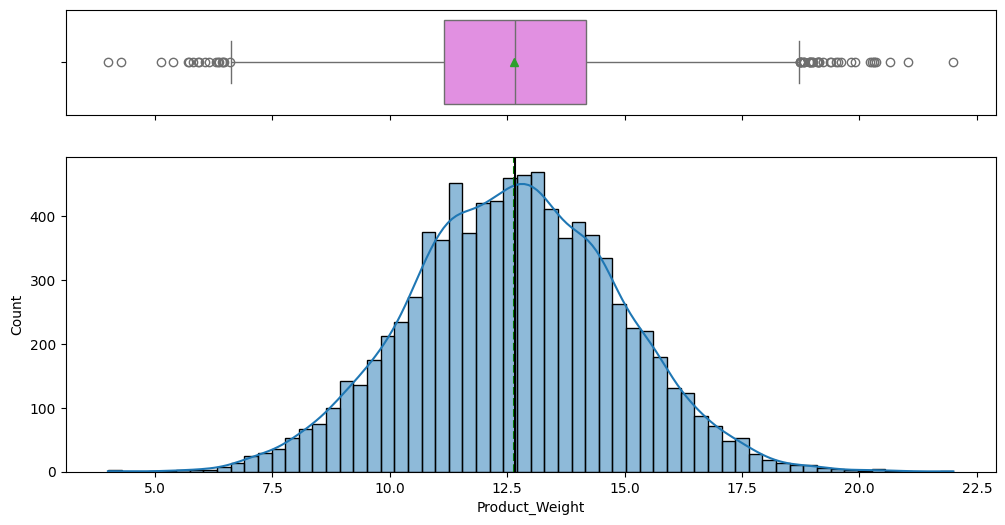

In [14]:
# Distribution and spread of Product_Weight
histogram_boxplot(data, "Product_Weight")

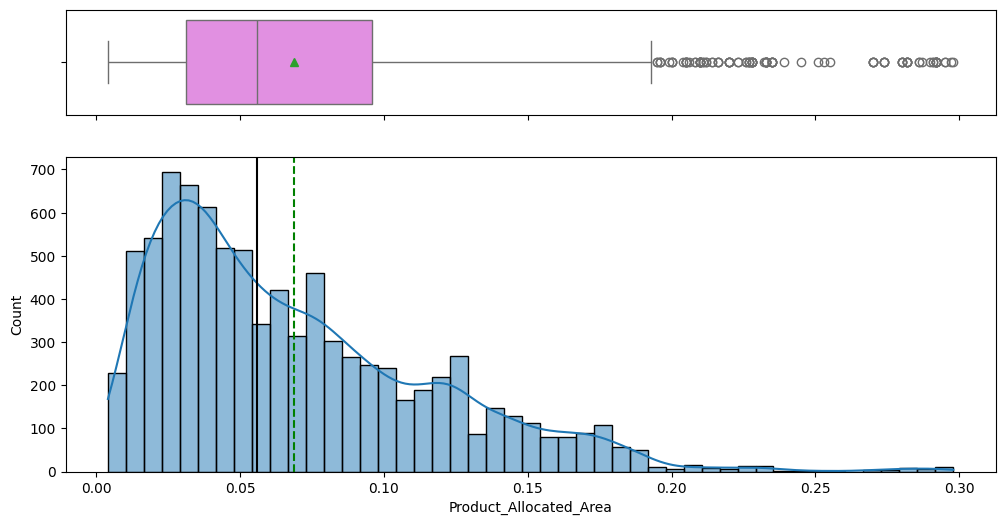

In [15]:
# Distribution and spread of Product_Allocated_Area
histogram_boxplot(data, "Product_Allocated_Area")

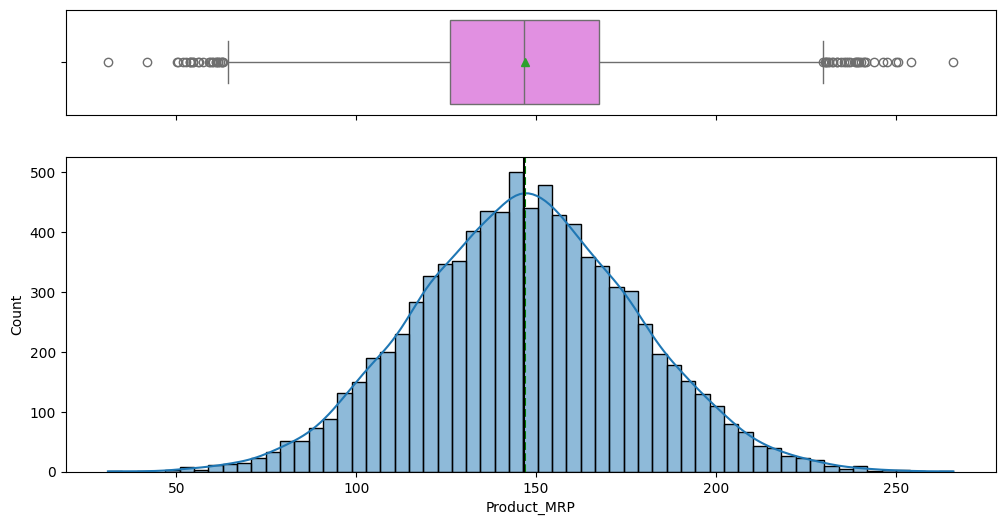

In [16]:
# Distribution and spread of Product_MRP
histogram_boxplot(data, "Product_MRP")

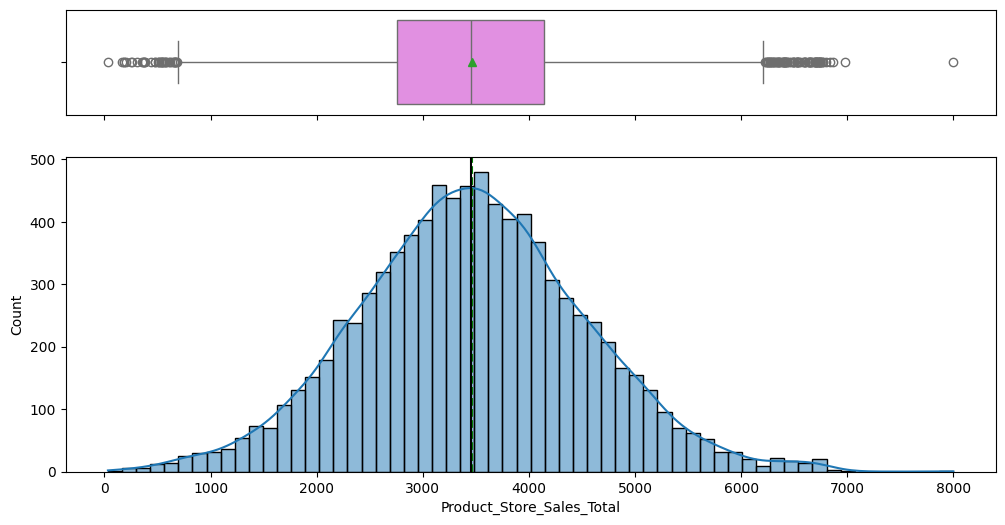

In [17]:
# Distribution and spread of Product_Store_Sales_Total
histogram_boxplot(data, "Product_Store_Sales_Total")

**Observations**
- `Product_Weight`, `Product_MRP` and `Product_Store_Sales_Total` are close to **normally distributed** with means ≈ medians; the few points outside the whiskers sit on both tails and are plausible values.
- `Product_Allocated_Area` is **right-skewed**: most products get under 10% of display area, a small number get up to ~30%.

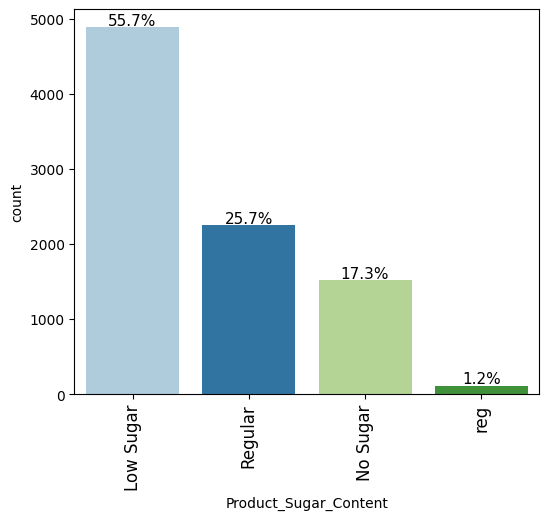

In [18]:
# Percentage of records in each level of Product_Sugar_Content
labeled_barplot(data, "Product_Sugar_Content", perc=True)

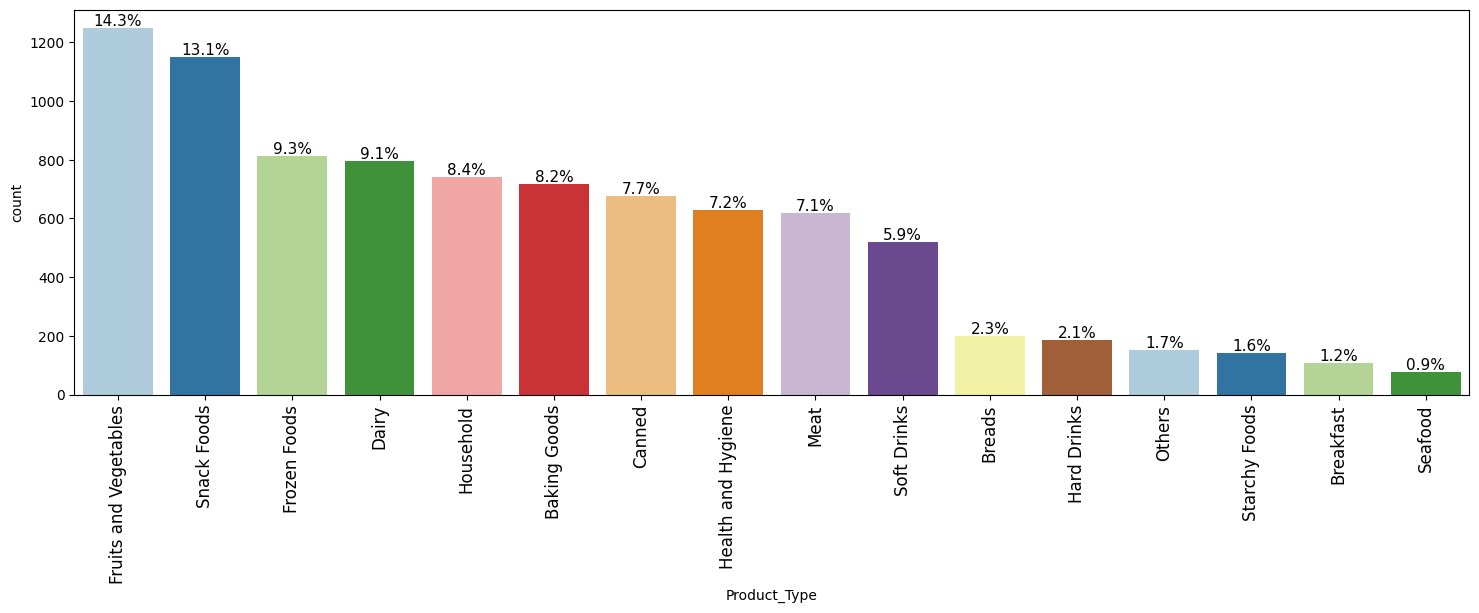

In [19]:
# Percentage of records in each level of Product_Type
labeled_barplot(data, "Product_Type", perc=True)

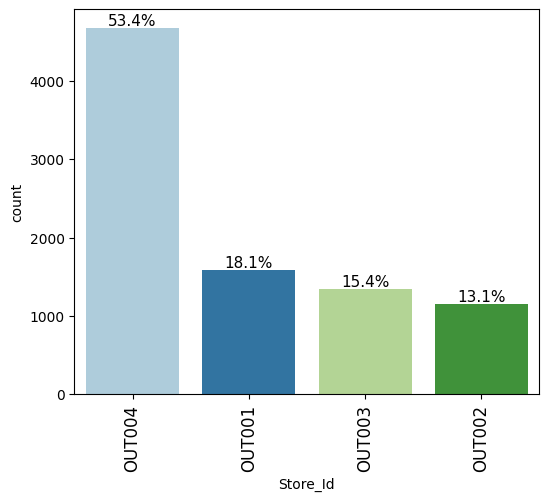

In [20]:
# Percentage of records in each level of Store_Id
labeled_barplot(data, "Store_Id", perc=True)

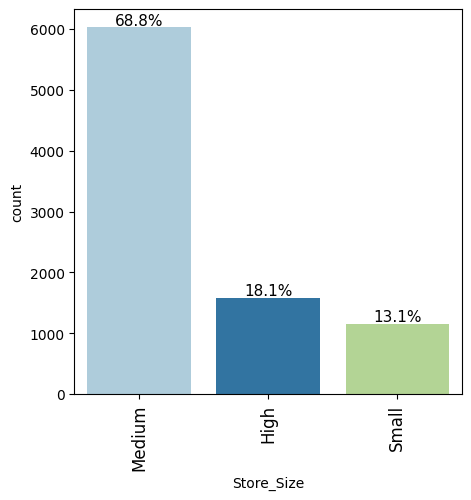

In [21]:
# Percentage of records in each level of Store_Size
labeled_barplot(data, "Store_Size", perc=True)

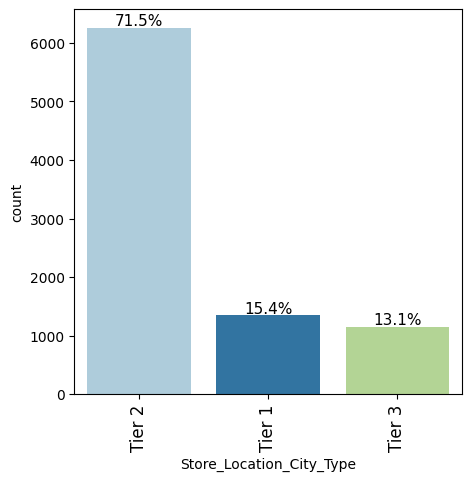

In [22]:
# Percentage of records in each level of Store_Location_City_Type
labeled_barplot(data, "Store_Location_City_Type", perc=True)

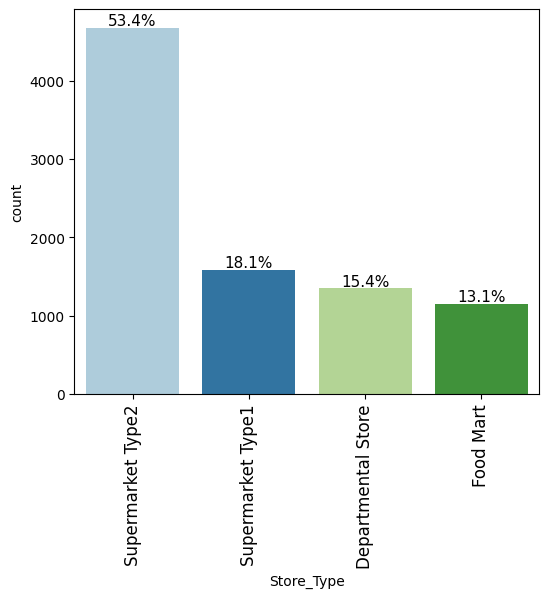

In [23]:
# Percentage of records in each level of Store_Type
labeled_barplot(data, "Store_Type", perc=True)

**Observations**
- **Low Sugar** products dominate (~56%), followed by Regular (~26% plus 1.2% `reg`) and No Sugar (~17%).
- **Fruits and Vegetables** (14%) and **Snack Foods** (13%) are the largest product types; Seafood, Breakfast and Starchy Foods are the smallest.
- **OUT004 (Supermarket Type2, Medium, Tier 2)** holds ~53% of all product–store records, so Medium stores and Tier 2 cities dominate the data.

## Bivariate Analysis

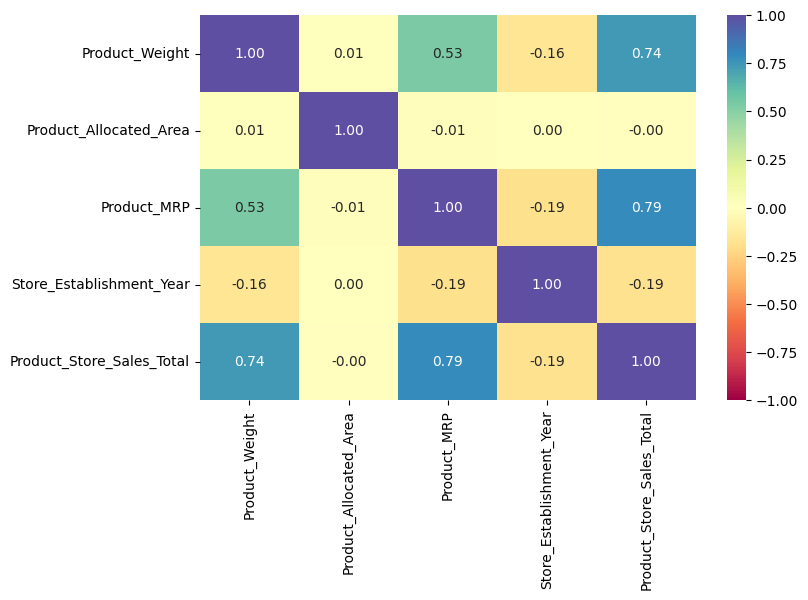

In [24]:
# Correlation among numeric variables
plt.figure(figsize=(8, 5))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f",
            cmap="Spectral", vmin=-1, vmax=1)
plt.show()

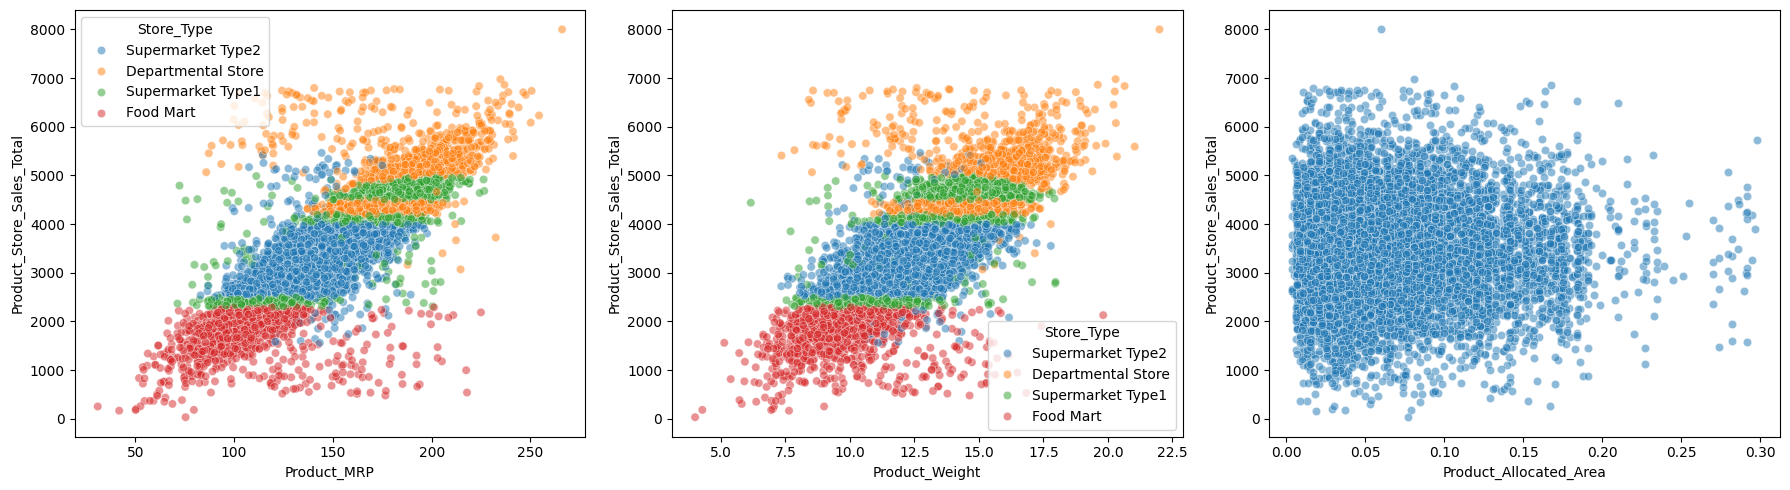

In [25]:
# Sales vs. the two strongest numeric drivers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=data, x="Product_MRP", y="Product_Store_Sales_Total", hue="Store_Type", alpha=0.5, ax=axes[0])
sns.scatterplot(data=data, x="Product_Weight", y="Product_Store_Sales_Total", hue="Store_Type", alpha=0.5, ax=axes[1])
sns.scatterplot(data=data, x="Product_Allocated_Area", y="Product_Store_Sales_Total", alpha=0.5, ax=axes[2])
plt.tight_layout()
plt.show()

**Observations**
- `Product_MRP` (r ≈ 0.79) and `Product_Weight` (r ≈ 0.74) have **strong positive linear relationships** with sales; they are the main numeric drivers.
- `Product_Allocated_Area` shows **no correlation** with sales (r ≈ 0.00): more shelf space does not by itself translate into more revenue.
- Colour by store type shows clear horizontal bands: at the same MRP, Departmental Stores sell the most and Food Marts the least.

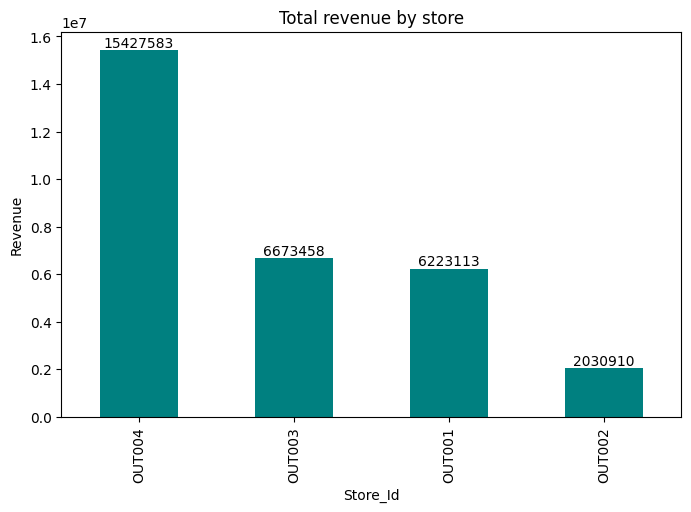

Store_Id
OUT004    50.8
OUT003    22.0
OUT001    20.5
OUT002     6.7
Name: Product_Store_Sales_Total, dtype: float64


In [26]:
# Total revenue contributed by each store
store_rev = data.groupby("Store_Id")["Product_Store_Sales_Total"].sum().sort_values(ascending=False)
ax = store_rev.plot(kind="bar", figsize=(8, 5), color="teal")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Total revenue by store")
plt.ylabel("Revenue")
plt.show()
print((store_rev / store_rev.sum() * 100).round(1))

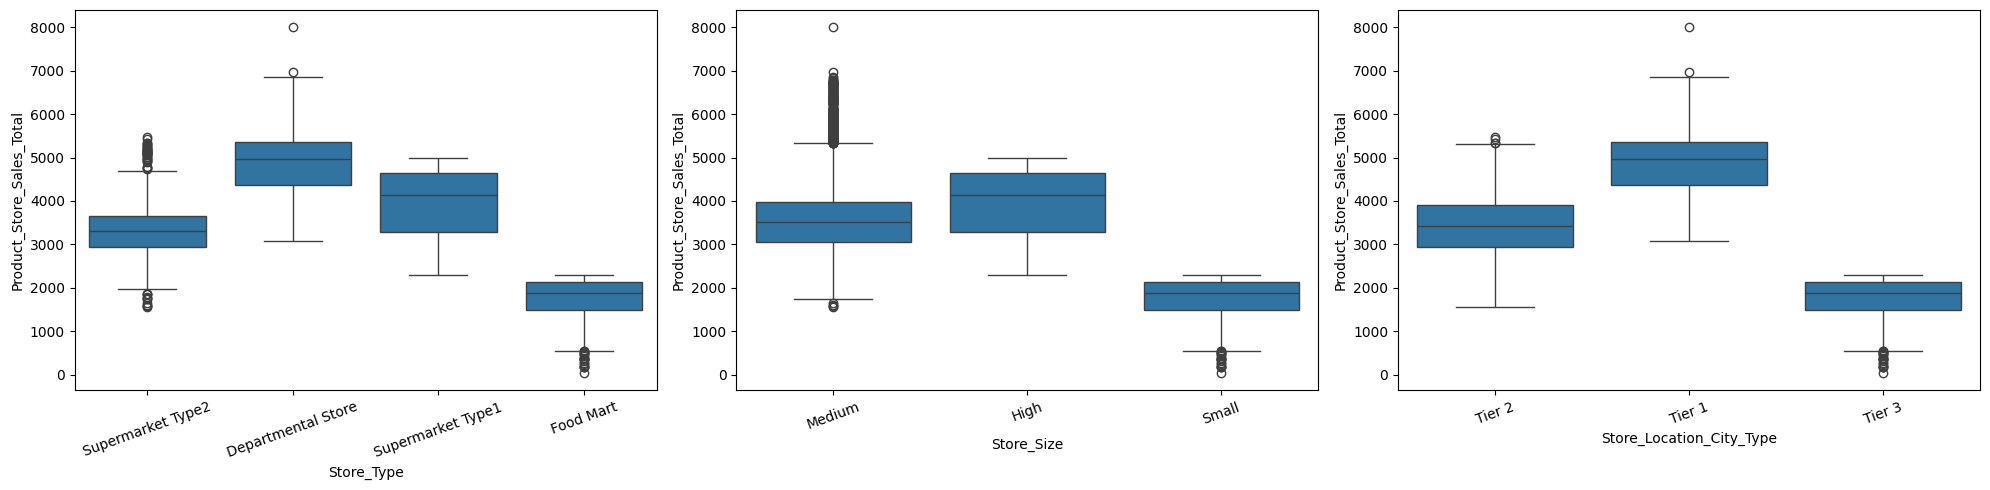

In [27]:
# Distribution of sales per product in each store type / size / city tier
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col in zip(axes, ["Store_Type", "Store_Size", "Store_Location_City_Type"]):
    sns.boxplot(data=data, x=col, y="Product_Store_Sales_Total", ax=ax)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

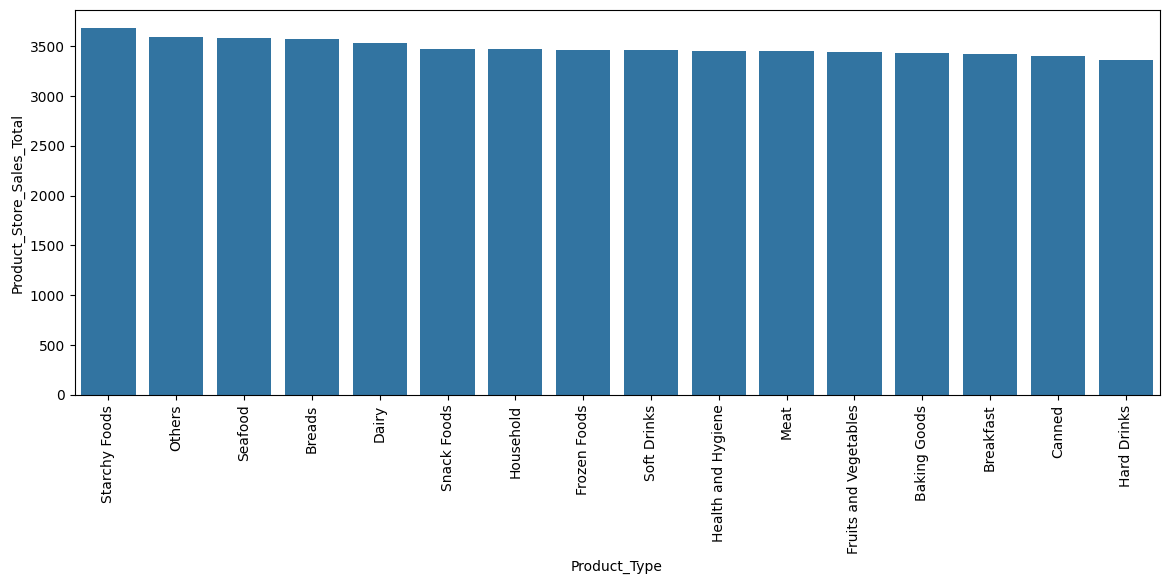

In [28]:
# Average sales per product by product type
plt.figure(figsize=(14, 5))
order = data.groupby("Product_Type")["Product_Store_Sales_Total"].mean().sort_values(ascending=False).index
sns.barplot(data=data, x="Product_Type", y="Product_Store_Sales_Total", order=order, errorbar=None)
plt.xticks(rotation=90)
plt.show()

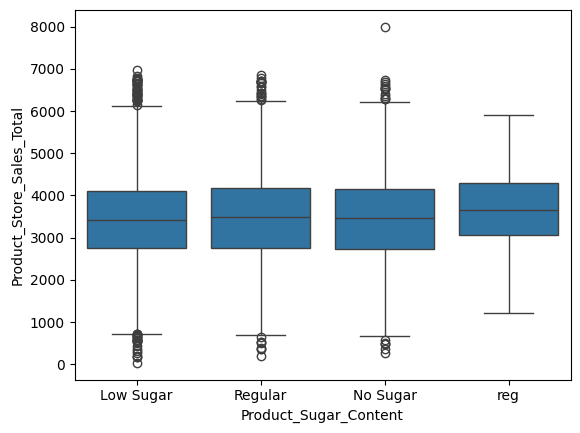

In [29]:
# Average sales by sugar content
sns.boxplot(data=data, x="Product_Sugar_Content", y="Product_Store_Sales_Total")
plt.show()

In [30]:
# Which product types earn the most in each store (revenue share)
pd.crosstab(data["Product_Type"], data["Store_Id"],
            values=data["Product_Store_Sales_Total"], aggfunc="sum").round(0)

Store_Id,OUT001,OUT002,OUT003,OUT004
Product_Type,,,,
Baking Goods,525131.0,169860.0,491908.0,1266086.0
Breads,121274.0,43419.0,175392.0,374857.0
Breakfast,38161.0,23396.0,95634.0,204939.0
Canned,449016.0,151468.0,452445.0,1247154.0
Dairy,598768.0,178888.0,715815.0,1318447.0
Frozen Foods,558557.0,180296.0,597608.0,1473520.0
Fruits and Vegetables,792993.0,298504.0,897437.0,2311900.0
Hard Drinks,152921.0,54282.0,110760.0,307852.0
Health and Hygiene,435005.0,164661.0,439139.0,1124902.0


In [31]:
# Price positioning of each store
data.groupby("Store_Id")[["Product_MRP", "Product_Store_Sales_Total"]].agg(["mean", "median"]).round(1)

Product_MRP        Product_Store_Sales_Total        
                mean median                      mean  median
Store_Id                                                     
OUT001         160.5  168.3                    3923.8  4139.6
OUT002         107.1  104.7                    1762.9  1889.5
OUT003         181.4  179.7                    4947.0  4958.3
OUT004         142.4  142.8                    3299.3  3304.2

**Observations**
- **OUT004 (Supermarket Type2)** brings in about **half of total revenue** (≈15.4M of 30.4M) because it stocks the largest number of products, even though its average revenue per product (~3,300) is mid-range.
- **OUT003 (Departmental Store, Tier 1)** has the **highest revenue per product** (~4,950) and also stocks the highest-MRP items. **OUT002 (Food Mart, Tier 3, Small)** has the lowest (~1,760) and the lowest-priced items.
- Revenue per product follows the store's positioning: Tier 1 > Tier 2 > Tier 3, and High/Medium > Small.
- Average revenue per product is very similar across product types and sugar-content levels; the product's price and weight matter more than its category.

**EDA summary**
1. Sales are driven mainly by **product MRP and weight** and by **which store** sells the product.
2. The store attributes (type, size, tier, age) are perfectly tied to the 4 stores, so the model effectively learns a store-level offset plus product effects.
3. Display area and product category have little standalone influence on revenue.

# **Data Preprocessing**

### Feature engineering
- **`Product_Sugar_Content`**: merge `reg` into `Regular`.
- **`Product_Id_char`**: first two characters of `Product_Id` (FD / NC / DR). The raw ID is unique per row and is dropped.
- **`Store_Age_Years`**: `2025 − Store_Establishment_Year`. Age is more interpretable than the year and matches the API payload (a 2009 store → 16 years).
- **`Product_Type_Category`**: group the 16 product types into **Perishables** (Dairy, Meat, Fruits and Vegetables, Breakfast, Breads, Seafood) and **Non Perishables** (everything else). This reduces cardinality and captures the shelf-life dimension that matters for inventory planning.
- Drop `Product_Id`, `Store_Id` (fully described by store attributes), `Product_Type` (replaced by its category) and `Store_Establishment_Year` (replaced by age).

In [32]:
# Fix the inconsistent sugar-content label
data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace("reg", "Regular")
data["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

In [33]:
# Extract the 2-letter product code from Product_Id
data["Product_Id_char"] = data["Product_Id"].str[:2]
data["Product_Id_char"].value_counts()

Product_Id_char
FD    6539
NC    1519
DR     705
Name: count, dtype: int64

In [34]:
# Check how product codes map to product types
pd.crosstab(data["Product_Type"], data["Product_Id_char"])

Product_Id_char,DR,FD,NC
Product_Type,,,
Baking Goods,0,716,0
Breads,0,200,0
Breakfast,0,106,0
Canned,0,677,0
Dairy,0,796,0
Frozen Foods,0,811,0
Fruits and Vegetables,0,1249,0
Hard Drinks,186,0,0
Health and Hygiene,0,0,628


In [35]:
# Store age in years (reference year 2025)
data["Store_Age_Years"] = 2025 - data["Store_Establishment_Year"]
data["Store_Age_Years"].value_counts()

Store_Age_Years
16    4676
38    1586
26    1349
27    1152
Name: count, dtype: int64

In [36]:
# Group product types into perishables and non-perishables
perishables = ["Dairy", "Meat", "Fruits and Vegetables", "Breakfast", "Breads", "Seafood"]
data["Product_Type_Category"] = np.where(data["Product_Type"].isin(perishables),
                                         "Perishables", "Non Perishables")
data["Product_Type_Category"].value_counts()

Product_Type_Category
Non Perishables    5718
Perishables        3045
Name: count, dtype: int64

In [37]:
# Revenue by the new category
data.groupby("Product_Type_Category")["Product_Store_Sales_Total"].describe()

,count,mean,std,min,25%,50%,75%,max
Product_Type_Category,,,,,,,,
Non Perishables,5718.0,3456.387541,1059.342895,33.00,2757.6425,3442.275,4132.0325,8000.00
Perishables,3045.0,3478.305399,1077.367798,166.92,2777.2700,3468.560,4161.3400,6835.81


### Outlier detection and treatment

In [38]:
# Share of values outside 1.5*IQR for each numeric column
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_pct = ((data[num_cols] < (Q1 - 1.5 * IQR)) | (data[num_cols] > (Q3 + 1.5 * IQR))).mean() * 100
outlier_pct.round(2)

Product_Weight               0.62
Product_Allocated_Area       1.19
Product_MRP                  0.65
Product_Store_Sales_Total    1.36
dtype: float64

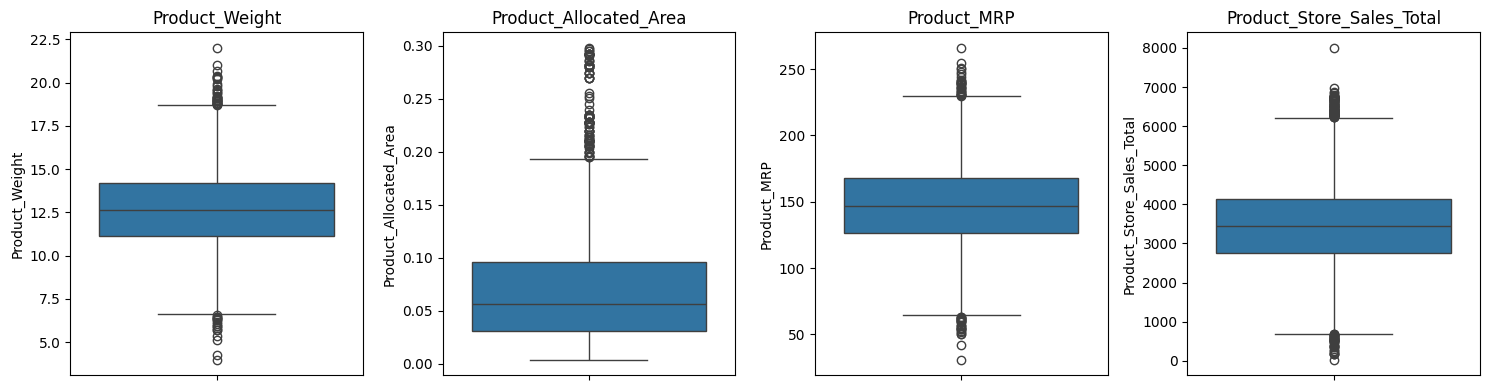

In [39]:
# Boxplots of numeric columns to visualise outliers
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Outlier treatment is not needed.**
- The flagged points are genuine values (a heavy or expensive product, a product given more shelf space) rather than data-entry errors, and they fall in realistic ranges.
- Removing or capping them would hide exactly the high-value products the business wants to forecast.
- The chosen models are tree ensembles, which split on thresholds and are robust to extreme values.

### Prepare the data for modelling
Split into **train (64%)**, **validation (16%)** and **test (20%)**. Models are compared on the validation set; the test set is held back to confirm the final model's performance.

In [40]:
# Features and target
drop_cols = ["Product_Id", "Store_Id", "Product_Type", "Store_Establishment_Year", "Product_Store_Sales_Total"]
X = data.drop(columns=drop_cols)
y = data["Product_Store_Sales_Total"]

# Train+validation vs. test, then train vs. validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=1)

print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)
X_train.head()

Train: (5608, 10)  Validation: (1402, 10)  Test: (1753, 10)


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
2970,11.66,Low Sugar,0.072,176.77,Medium,Tier 2,Supermarket Type2,FD,16,Perishables
807,13.25,Regular,0.050,102.22,Medium,Tier 2,Supermarket Type2,FD,16,Perishables
4394,13.04,Low Sugar,0.172,154.12,Medium,Tier 2,Supermarket Type2,FD,16,Perishables
3080,12.25,Low Sugar,0.025,153.72,Medium,Tier 2,Supermarket Type2,FD,16,Non Perishables
6068,16.62,Regular,0.017,179.67,Medium,Tier 1,Departmental Store,FD,26,Perishables


### Preprocessing pipeline
- Numeric features → `StandardScaler` (does not change tree splits, but keeps the pipeline ready for any model).
- Categorical features → `OneHotEncoder(handle_unknown="ignore")`, so the deployed API does not fail on a category it never saw in training (for example `Supermarket Type3` in the batch file).

In [41]:
# Numeric features are scaled, categorical features are one-hot encoded
numeric_features = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]
categorical_features = ["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type",
                        "Store_Type", "Product_Id_char", "Product_Type_Category"]

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

# **Model Building**

## Choice of metric
**RMSE** is the primary metric.
- It is expressed in the same unit as revenue, so the business can read it as “typical forecast error in currency”.
- It penalises large misses more than small ones; a big under-forecast (stock-out) or over-forecast (excess inventory) for a high-value product is costlier than several small errors.
- R², adjusted R², MAE and MAPE are also reported for context.

## Define functions for Model Evaluation

In [42]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

We build **Random Forest** (bagging of deep trees, lowers variance) and **XGBoost** (sequential boosting, lowers bias). Each is wrapped in a pipeline with the preprocessing step so the saved model takes raw feature columns directly.

### Random Forest

In [43]:
# Random Forest with default parameters, chained after the preprocessing step
rf_estimator = make_pipeline(preprocessor, RandomForestRegressor(random_state=1))
rf_estimator.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [44]:
# Performance on the training set
rf_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,109.643798,41.294809,0.989366,0.989347,0.015112


In [45]:
# Performance on the validation set
rf_val_perf = model_performance_regression(rf_estimator, X_val, y_val)
rf_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,261.307112,100.711109,0.939633,0.939199,0.043711


### XGBoost

In [46]:
# XGBoost with default parameters, chained after the preprocessing step
xgb_estimator = make_pipeline(preprocessor, XGBRegressor(random_state=1))
xgb_estimator.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [47]:
# Performance on the training set
xgb_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,120.784384,58.044539,0.987096,0.987072,0.020241


In [48]:
# Performance on the validation set
xgb_val_perf = model_performance_regression(xgb_estimator, X_val, y_val)
xgb_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,286.719694,133.027277,0.92732,0.926798,0.05707


**Observations**
- Both default models explain over 90% of the variance on unseen data, confirming that MRP, weight and store attributes are strong predictors.
- Both **overfit**: training R² is ~0.98–0.99 with RMSE ~110–140, while validation RMSE is roughly two to three times higher. The default Random Forest grows trees to full depth, and default XGBoost adds 100 fairly deep boosting rounds.
- Hyperparameter tuning should limit tree depth / complexity to close this gap.

# **Model Performance Improvement - Hyperparameter Tuning**

`GridSearchCV` with 5-fold cross-validation on the training set, optimising **negative RMSE** (the chosen metric).

### Tuned Random Forest

In [49]:
# Grid search over Random Forest hyperparameters, scored on RMSE with 5-fold CV
rf_tuned = make_pipeline(preprocessor, RandomForestRegressor(random_state=1))

rf_params = {
    "randomforestregressor__n_estimators": [50, 100, 150],
    "randomforestregressor__max_depth": [6, 10, None],
    "randomforestregressor__max_features": [0.5, 1.0],
    "randomforestregressor__min_samples_leaf": [1, 3],
}

rf_grid = GridSearchCV(rf_tuned, rf_params, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_tuned = rf_grid.best_estimator_
print("Best parameters:", rf_grid.best_params_)
print("Best CV RMSE:", round(-rf_grid.best_score_, 2))

Best parameters: {'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 1.0, 'randomforestregressor__min_samples_leaf': 3, 'randomforestregressor__n_estimators': 100}
Best CV RMSE: 287.97


In [50]:
# Performance on the training set
rf_tuned_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,203.722409,73.529185,0.963289,0.963223,0.026723


In [51]:
# Performance on the validation set
rf_tuned_val_perf = model_performance_regression(rf_tuned, X_val, y_val)
rf_tuned_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,256.903819,99.084565,0.94165,0.941231,0.048906


### Tuned XGBoost

In [52]:
# Grid search over XGBoost hyperparameters, scored on RMSE with 5-fold CV
xgb_tuned = make_pipeline(preprocessor, XGBRegressor(random_state=1))

xgb_params = {
    "xgbregressor__n_estimators": [50, 100, 200],
    "xgbregressor__max_depth": [3, 5, 7],
    "xgbregressor__learning_rate": [0.05, 0.1, 0.2],
    "xgbregressor__subsample": [0.7, 1.0],
}

xgb_grid = GridSearchCV(xgb_tuned, xgb_params, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_tuned = xgb_grid.best_estimator_
print("Best parameters:", xgb_grid.best_params_)
print("Best CV RMSE:", round(-xgb_grid.best_score_, 2))

Best parameters: {'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 100, 'xgbregressor__subsample': 0.7}
Best CV RMSE: 292.07


In [53]:
# Performance on the training set
xgb_tuned_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,211.628958,82.01141,0.960384,0.960313,0.029439


In [54]:
# Performance on the validation set
xgb_tuned_val_perf = model_performance_regression(xgb_tuned, X_val, y_val)
xgb_tuned_val_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,258.51603,104.27803,0.940915,0.940491,0.050948


**Observations**
- Tuning regularised both models. Training scores dropped slightly while validation RMSE improved, so the **train–validation gap narrowed** and both tuned models generalise better than their defaults.
- Random Forest tuning chose `min_samples_leaf=3` (smoother leaves); XGBoost tuning chose a lower learning rate (0.05) with row subsampling (0.7). Both are forms of regularisation.
- The tuned models remain very accurate: validation R² ≈ 0.94 and MAPE of about 5%.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [55]:
# Side-by-side training metrics of all four models
models_train_comp_df = pd.concat(
    [rf_train_perf.T, rf_tuned_train_perf.T, xgb_train_perf.T, xgb_tuned_train_perf.T], axis=1)
models_train_comp_df.columns = ["Random Forest", "Random Forest Tuned", "XGBoost", "XGBoost Tuned"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,109.643798,203.722409,120.784384,211.628958
MAE,41.294809,73.529185,58.044539,82.011410
R-squared,0.989366,0.963289,0.987096,0.960384
Adj. R-squared,0.989347,0.963223,0.987072,0.960313
MAPE,0.015112,0.026723,0.020241,0.029439


In [56]:
# Side-by-side validation metrics of all four models
models_val_comp_df = pd.concat(
    [rf_val_perf.T, rf_tuned_val_perf.T, xgb_val_perf.T, xgb_tuned_val_perf.T], axis=1)
models_val_comp_df.columns = ["Random Forest", "Random Forest Tuned", "XGBoost", "XGBoost Tuned"]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,261.307112,256.903819,286.719694,258.516030
MAE,100.711109,99.084565,133.027277,104.278030
R-squared,0.939633,0.941650,0.927320,0.940915
Adj. R-squared,0.939199,0.941231,0.926798,0.940491
MAPE,0.043711,0.048906,0.057070,0.050948


In [57]:
# Gap between train and validation RMSE (smaller = less overfitting)
(models_val_comp_df.loc["RMSE"] - models_train_comp_df.loc["RMSE"]).round(2)

Random Forest          151.66
Random Forest Tuned     53.18
XGBoost                165.94
XGBoost Tuned           46.89
Name: RMSE, dtype: float64

In [58]:
# Pick the model with the lowest validation RMSE
best_name = models_val_comp_df.loc["RMSE"].idxmin()
candidates = {"Random Forest": rf_estimator, "Random Forest Tuned": rf_tuned,
              "XGBoost": xgb_estimator, "XGBoost Tuned": xgb_tuned}
best_model = candidates[best_name]
print("Selected model:", best_name)

Selected model: Random Forest Tuned


**Final model selection**
**Tuned Random Forest** is selected:
- It has the **lowest validation RMSE (≈257)** and MAE (≈99) and the highest validation R² (≈0.94) of all four models.
- Its train–validation RMSE gap (≈53) is about a third of the default Random Forest's (≈152), so it generalises far better; tuned XGBoost is close behind but slightly less accurate.
- On the untouched **test set** it scores RMSE ≈ 288, R² ≈ 0.93 and MAPE ≈ 3.8% (below), consistent with validation, confirming there is no overfitting to the validation data.

In [59]:
# Final check of the selected model on the unseen test set
best_test_perf = model_performance_regression(best_model, X_test, y_test)
print(f"Test performance of {best_name}:")
best_test_perf

Test performance of Random Forest Tuned:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.475229,107.961087,0.927808,0.927393,0.037912


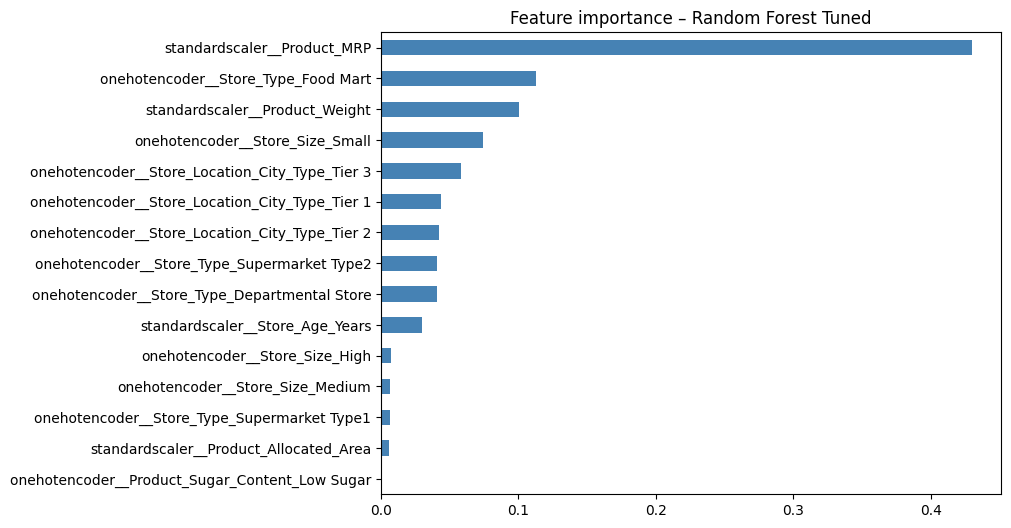

In [60]:
# Feature importance of the final model
est = best_model[-1]
feat_names = best_model[0].get_feature_names_out()
imp = pd.Series(est.feature_importances_, index=feat_names).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title(f"Feature importance – {best_name}")
plt.show()

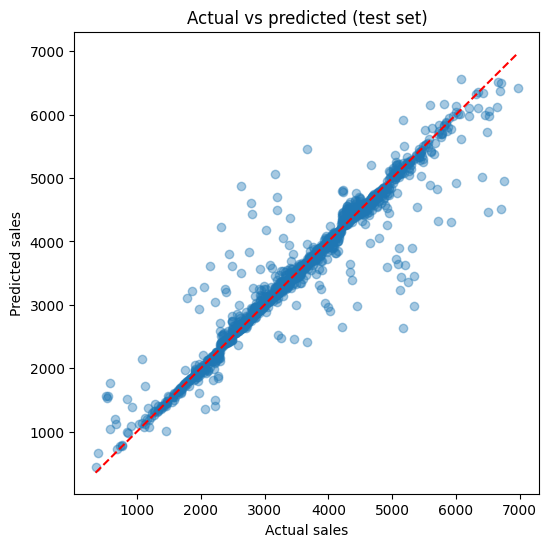

In [61]:
# Actual vs predicted on the test set
pred_test = best_model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_test, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual sales"); plt.ylabel("Predicted sales")
plt.title("Actual vs predicted (test set)")
plt.show()

### Serialization

In [62]:
# Folder for all backend deployment files
os.makedirs("backend_files", exist_ok=True)

# Save the full pipeline (preprocessing + model)
saved_model_path = "backend_files/superkart_model.joblib"
joblib.dump(best_model, saved_model_path)
print("Model saved to", saved_model_path)

Model saved to backend_files/superkart_model.joblib


In [63]:
# Load the serialized model and predict on the test set
loaded_model = joblib.load(saved_model_path)
print("Loaded model predictions match:", np.allclose(loaded_model.predict(X_test), pred_test))
model_performance_regression(loaded_model, X_test, y_test)

Loaded model predictions match: True


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.475229,107.961087,0.927808,0.927393,0.037912


# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [64]:
%%writefile backend_files/app.py
# Flask API serving the SuperKart sales forecasting model
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize the Flask app
superkart_api = Flask("SuperKart Sales Predictor")

# Load the trained pipeline (preprocessing + model) once at start-up
model = joblib.load("superkart_model.joblib")

# Feature columns expected by the model, in training order
FEATURES = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP",
    "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char",
    "Store_Age_Years", "Product_Type_Category",
]


@superkart_api.get("/")
def home():
    """Health-check / landing route."""
    return "Welcome to the SuperKart Sales Forecasting API!"


@superkart_api.post("/v1/predict")
def predict_sales():
    """Online inference: predict sales for one product-store record sent as JSON."""
    data = request.get_json()
    missing = [f for f in FEATURES if f not in data]
    if missing:
        return jsonify({"error": f"Missing fields: {missing}"}), 400

    # Build a one-row DataFrame in the order the model expects
    sample = pd.DataFrame([{f: data[f] for f in FEATURES}])
    prediction = float(model.predict(sample)[0])

    return jsonify({"Predicted Sales": round(prediction, 2)})


@superkart_api.post("/v1/predictbatch")
def predict_sales_batch():
    """Batch inference: predict sales for every row of an uploaded CSV file."""
    file = request.files.get("file")
    if file is None:
        return jsonify({"error": "Upload a CSV file under the key 'file'"}), 400

    input_data = pd.read_csv(file)
    missing = [f for f in FEATURES if f not in input_data.columns]
    if missing:
        return jsonify({"error": f"Missing columns: {missing}"}), 400

    predictions = model.predict(input_data[FEATURES])
    # Map each row index to its predicted sales
    output = {str(i): round(float(p), 2) for i, p in zip(input_data.index, predictions)}
    return jsonify(output)


if __name__ == "__main__":
    superkart_api.run(host="0.0.0.0", port=7860, debug=False)

Writing backend_files/app.py


## Dependencies File

In [65]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.4

Writing backend_files/requirements.txt


The versions of pandas, numpy, scikit-learn, xgboost and joblib match the notebook so the serialized pipeline loads without version conflicts.

## Dockerfile

In [66]:
%%writefile backend_files/Dockerfile
# Lightweight Python base image
FROM python:3.11-slim

# Working directory inside the container
WORKDIR /app

# Install dependencies first to take advantage of Docker layer caching
COPY requirements.txt .
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Copy the API code and the serialized model
COPY . .

# Flask API listens on port 7860
EXPOSE 7860

# Serve the app with gunicorn: 4 workers, bound to all interfaces on port 7860
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [67]:
# Folder for all frontend deployment files
os.makedirs("frontend_files", exist_ok=True)

In [68]:
%%writefile frontend_files/app.py
# Streamlit UI for the SuperKart sales forecasting API
import os
import requests
import pandas as pd
import streamlit as st

# Backend URL: inside the Docker network the Flask container is reachable by its name
BACKEND_URL = os.getenv("BACKEND_URL", "http://superkart-backend:7860")

st.set_page_config(page_title="SuperKart Sales Forecast", page_icon="🛒")
st.title("SuperKart Sales Forecasting")
st.write("Predict the total sales revenue of a product in a SuperKart store.")

# ---------------- Online prediction ----------------
st.subheader("Online prediction")

col1, col2 = st.columns(2)
with col1:
    product_weight = st.number_input("Product Weight", min_value=0.0, max_value=50.0, value=12.66, step=0.1)
    product_sugar = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
    product_area = st.number_input("Product Allocated Area (ratio)", min_value=0.0, max_value=1.0,
                                   value=0.027, step=0.001, format="%.3f")
    product_mrp = st.number_input("Product MRP", min_value=0.0, max_value=500.0, value=117.08, step=0.5)
    product_code = st.selectbox("Product Id prefix", ["FD", "NC", "DR"],
                                help="FD = Food, NC = Non-consumable, DR = Drinks")
with col2:
    product_category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])
    store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    store_city = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
    store_type = st.selectbox("Store Type", ["Departmental Store", "Supermarket Type1",
                                             "Supermarket Type2", "Food Mart"])
    store_age = st.number_input("Store Age (years)", min_value=0, max_value=100, value=16, step=1)

payload = {
    "Product_Weight": product_weight,
    "Product_Sugar_Content": product_sugar,
    "Product_Allocated_Area": product_area,
    "Product_MRP": product_mrp,
    "Store_Size": store_size,
    "Store_Location_City_Type": store_city,
    "Store_Type": store_type,
    "Product_Id_char": product_code,
    "Store_Age_Years": int(store_age),
    "Product_Type_Category": product_category,
}

if st.button("Predict", type="primary"):
    try:
        response = requests.post(f"{BACKEND_URL}/v1/predict", json=payload, timeout=30)
        if response.status_code == 200:
            result = response.json()["Predicted Sales"]
            st.success(f"Predicted Product Store Sales Total: {result:,.2f}")
        else:
            st.error(f"API error {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"Could not reach the backend at {BACKEND_URL}: {e}")

# ---------------- Batch prediction ----------------
st.subheader("Batch prediction")
uploaded_file = st.file_uploader("Upload a CSV file with the model's feature columns", type=["csv"])

if uploaded_file is not None and st.button("Predict batch"):
    try:
        response = requests.post(f"{BACKEND_URL}/v1/predictbatch",
                                 files={"file": uploaded_file.getvalue()}, timeout=60)
        if response.status_code == 200:
            preds = response.json()
            uploaded_file.seek(0)
            df = pd.read_csv(uploaded_file)
            df["Predicted_Sales"] = [preds[str(i)] for i in df.index]
            st.dataframe(df)
            st.download_button("Download predictions", df.to_csv(index=False),
                               file_name="superkart_predictions.csv", mime="text/csv")
        else:
            st.error(f"API error {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"Could not reach the backend at {BACKEND_URL}: {e}")

Writing frontend_files/app.py


## Dependencies File

In [69]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.32.4
streamlit==1.43.2

Writing frontend_files/requirements.txt


## Dockerfile

In [70]:
%%writefile frontend_files/Dockerfile
# Lightweight Python base image
FROM python:3.11-slim

WORKDIR /app

# Install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the Streamlit app
COPY . .

# Streamlit listens on port 8501
EXPOSE 8501

# Run Streamlit on all interfaces; disable XSRF/CORS so it works behind the Codespaces proxy
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false", "--server.enableCORS=false"]

Writing frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

The notebook is run inside a **GitHub Codespace** opened on the project repository. The Codespace is already a clone of the repository and is signed in to GitHub, so no Personal Access Token is needed; the deployment folders are committed and pushed directly.

*(If running from Colab instead, clone the repository with a Personal Access Token and push the same two folders.)*

In [ ]:
# Copy the batch file into the frontend folder so it can also be tested from the Streamlit UI
import shutil
shutil.copy("Batch_Data_SuperKart.csv", "frontend_files/Batch_Data_SuperKart.csv")

In [ ]:
# Commit the backend and frontend folders and push them to the GitHub repository
!git add backend_files frontend_files
!git commit -m "Add SuperKart Flask backend and Streamlit frontend"
!git push

### Run both containers in the GitHub Codespace
Run in the Codespace terminal:

```bash
# 1. Create a Docker network for the application
docker network create superkart-net

# 2. Build and run the Flask backend (API on port 7860)
docker build -t superkart-backend ./backend_files
docker run -d --name superkart-backend --network superkart-net -p 7860:7860 superkart-backend

# 3. Build and run the Streamlit frontend (UI on port 8501)
docker build -t superkart-frontend ./frontend_files
docker run -d --name superkart-frontend --network host \
  -e BACKEND_URL=http://localhost:7860 superkart-frontend

# 4. Check both are up
docker ps
curl http://localhost:7860/
```

**Note on networking:** inside Codespaces, traffic between two containers on the same user-defined Docker network was blocked (the frontend timed out calling `http://superkart-backend:7860` even though the backend was healthy). The frontend therefore runs on the Codespace's host network and reaches the backend through its published port `localhost:7860`. The frontend reads the backend address from the `BACKEND_URL` environment variable, so no code change was needed.

In the **Ports** tab, set **7860** (API) and **8501** (UI) to **Public** and copy the forwarded URL for port 7860.

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [71]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [72]:
model_root_url = "https://<your-codespace-name>-7860.app.github.dev"  # Replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [73]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [74]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [75]:
# One product-store record with the same feature columns the model was trained on
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [ ]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [ ]:
# HTTP status of the request
response

`<Response [200]>` indicates that the HTTP request was successful.

- `Response` is the object returned by `requests.post()`.
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).

In [ ]:
# Predicted sales returned by the API
print(response.json())

Expected output (verified against the same model locally): `{'Predicted Sales': 2861.29}`

`response.json()` is used to parse the response body as JSON.
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.
- This allows easy access to specific values using keys.

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [76]:
# Load the records to score in one request
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [77]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [ ]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [ ]:
# HTTP status of the request
response

In [ ]:
# Extract predictions from API response
response.text

Expected output (verified locally): `{"0": 4378.18, "1": 3326.39, "2": 4066.15, "3": 1783.04, "4": 4018.07, "5": 5203.93, "6": 2549.53, "7": 2307.21, "8": 4813.81, "9": 2764.11}`

In [ ]:
# Attach the predictions to the batch data for easy reading
batch_dataset["Predicted_Sales"] = pd.Series(response.json()).astype(float).values
batch_dataset

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

### Insights
- **Price and weight drive revenue.** `Product_MRP` is the single most important feature (~43% of model importance, r ≈ 0.79 with sales), followed by `Product_Weight` (r ≈ 0.74). Higher-priced, heavier products generate the most revenue per store.
- **Store format sets the revenue level.** At the same price, a Departmental Store (Tier 1) earns about 4,950 per product, Supermarket Type1 about 3,920, Supermarket Type2 about 3,300 and the Food Mart (Tier 3, Small) only about 1,760. Food Mart / Small / Tier 3 flags are the next most important features.
- **One store carries the business.** OUT004 (Supermarket Type2, Tier 2) delivers **~51% of total revenue** thanks to its broad assortment, while OUT002 (Food Mart) contributes under 7%.
- **Shelf space is not being used effectively.** `Product_Allocated_Area` has essentially zero correlation with sales, so current display allocation is not aligned with what sells.
- **Category matters less than price.** Perishables and non-perishables, and all sugar-content levels, have almost identical average revenue per product.
- **Model quality.** The tuned Random Forest predicts product–store revenue on unseen test data with **R² ≈ 0.93, RMSE ≈ 288 and MAPE ≈ 3.8%**, accurate enough for quarterly planning. It is deployed as a Flask API (online + batch) with a Streamlit UI, running as two Docker containers on a shared Docker network.

### Business recommendations
1. **Use the forecast for quarterly procurement.** Run the batch endpoint on the planned assortment each quarter and size purchase orders per store from the predicted revenue, starting with high-MRP items where a forecasting miss costs the most.
2. **Re-allocate shelf space by predicted revenue.** Since display area currently has no link to sales, give more space to high-MRP, high-forecast products and trim space for low-forecast items; re-measure the effect after one quarter.
3. **Protect and replicate OUT004.** Prioritise stock availability and supply-chain reliability for the Supermarket Type2 outlet, and use its wide-assortment model as the template when expanding in Tier 2 cities.
4. **Push premium ranges in Tier 1 / Departmental formats.** OUT003 earns the most per product; expand its premium, higher-MRP assortment.
5. **Rethink the Food Mart.** OUT002 contributes under 7% of revenue. Focus it on fast-moving, lower-price essentials, test targeted promotions, or review its format before investing further in Tier 3 food marts.
6. **Keep the model fresh.** Retrain every quarter with new sales data, and add time-based and promotional features (season, discounts, footfall) as they become available; add new stores' data before using the model for new formats such as Supermarket Type3, which the model has not seen.

### Conclusion
SuperKart's product-store revenue is predictable mainly from product price, weight and the selling store's format. The tuned Random Forest pipeline achieves roughly 4% average percentage error and is packaged as a containerised, decoupled API + UI that supply-chain and regional teams can use for both single what-if checks and bulk quarterly forecasts.